In [1]:
import pandas as pd
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [9]:
transfer_metric_name="FD" # "DS" or "FD"
dataset_name_source_list = ["dwq_sentinel2", "xj_sentinel2"]
dataset_name_target_list = dataset_name_source_list[::-1]
batch_size = 4
# result_path = r"E:\Yiling\at_SIAT_research\z_result\20241025_transfer_metric_FD_weighted_y_diff\20241025_6_label1_FID_all-batch4_dwqs2-xjs2_100img"
# result_path = r"E:\Yiling\at_SIAT_research\z_result\20241025_transfer_metric_FD_weighted_y_diff\20241025_2_-_FID_all-batch4_dwqs2-xjs2_100img"
result_path = r"E:\Yiling\at_SIAT_research\z_result\20241210_transfer_metric_FD_cross_sensor_batch14_FD\20241210_1734_1_dwq_s2_xj_s2_\8_label1_FID_all-batch4_100img"

# load the result_list_dict
result_list_dict_name = f"result_list_dict_{dataset_name_source_list[0]}-{dataset_name_target_list[0]}_batch{batch_size}.json"
result_list_dict_path = os.path.join(result_path, result_list_dict_name)
with open(result_list_dict_path, 'r') as f:
    result_list_dict = json.load(f)

for key in result_list_dict.keys():
    source = result_list_dict[key][0][0]
    target = result_list_dict[key][0][1]
    print(key, len(result_list_dict[key]), len(result_list_dict[key][0]), source, target)

dwq_sentinel2_cls_1 90 32 dwq_sentinel2 xj_sentinel2
dwq_sentinel2_cls_2 1 32 dwq_sentinel2 xj_sentinel2
dwq_sentinel2_cls_3 37 32 dwq_sentinel2 xj_sentinel2
dwq_sentinel2_cls_6 16 32 dwq_sentinel2 xj_sentinel2
dwq_sentinel2_cls_7 4 32 dwq_sentinel2 xj_sentinel2
dwq_sentinel2_cls_8 296 32 dwq_sentinel2 xj_sentinel2
xj_sentinel2_cls_1 109 32 xj_sentinel2 dwq_sentinel2
xj_sentinel2_cls_2 512 32 xj_sentinel2 dwq_sentinel2
xj_sentinel2_cls_3 4 32 xj_sentinel2 dwq_sentinel2
xj_sentinel2_cls_6 44 32 xj_sentinel2 dwq_sentinel2
xj_sentinel2_cls_7 151 32 xj_sentinel2 dwq_sentinel2
xj_sentinel2_cls_8 49 32 xj_sentinel2 dwq_sentinel2


In [3]:
result_list_name_path = os.path.join(result_path, "result_list_name.json")
with open(result_list_name_path, "r") as file:
    result_list_name = json.load(file)
print(len(result_list_name))
for i in range(len(result_list_name)):
    print(i, result_list_name[i])

32
0 source
1 target
2 class_index
3 class_name
4 OA_delta
5 F1_delta
6 precision_delta
7 mean_dif_absolute_sum
8 mean_dif_absolute_abs_sum
9 mean_dif_relative_sum
10 mean_dif_relative_abs_sum
11 mean_dif_absolute_y0_y1_diff
12 mean_dif_absolute_abs_y0_y1_diff
13 mean_dif_relative_y0_y1_diff
14 mean_dif_relative_abs_y0_y1_diff
15 mean_dif_absolute_y0_y1_diff_abs
16 mean_dif_absolute_abs_y0_y1_diff_abs
17 mean_dif_relative_y0_y1_diff_abs
18 mean_dif_relative_abs_y0_y1_diff_abs
19 mean_dif_absolute_y0_y1_diff_normalized
20 mean_dif_absolute_abs_y0_y1_diff_normalized
21 mean_dif_relative_y0_y1_diff_normalized
22 mean_dif_relative_abs_y0_y1_diff_normalized
23 mean_dif_absolute_y0_y1_diff_abs_normalized
24 mean_dif_absolute_abs_y0_y1_diff_abs_normalized
25 mean_dif_relative_y0_y1_diff_abs_normalized
26 mean_dif_relative_abs_y0_y1_diff_abs_normalized
27 FD_sum
28 FD_y0_y1_diff
29 FD_y0_y1_diff_abs
30 FD_y0_y1_diff_normalized
31 FD_y0_y1_diff_abs_normalized


In [4]:
df_dict = {}
for key in result_list_dict.keys():
    source = result_list_dict[key][0][0]
    target = result_list_dict[key][0][1]
    key_new = key.replace(f"{source}", f"{source}-{target}")
    df_dict[key_new] = pd.DataFrame(result_list_dict[key], columns=result_list_name)

for key in df_dict.keys():
    print(key, df_dict[key].shape)

dwq_sentinel2-xj_sentinel2_cls_1 (90, 32)
dwq_sentinel2-xj_sentinel2_cls_2 (1, 32)
dwq_sentinel2-xj_sentinel2_cls_3 (37, 32)
dwq_sentinel2-xj_sentinel2_cls_6 (16, 32)
dwq_sentinel2-xj_sentinel2_cls_7 (4, 32)
dwq_sentinel2-xj_sentinel2_cls_8 (296, 32)
xj_sentinel2-dwq_sentinel2_cls_1 (109, 32)
xj_sentinel2-dwq_sentinel2_cls_2 (512, 32)
xj_sentinel2-dwq_sentinel2_cls_3 (4, 32)
xj_sentinel2-dwq_sentinel2_cls_6 (44, 32)
xj_sentinel2-dwq_sentinel2_cls_7 (151, 32)
xj_sentinel2-dwq_sentinel2_cls_8 (49, 32)


In [5]:
# 从 OA_delta 往后取
selected_columns = result_list_name[4:]

df_corr_F1_diff = pd.DataFrame(columns=selected_columns)

index_name = "F1_delta" # F1_delta
correlation_method = "pearson" # pearson, spearman
for key in df_dict.keys():
    temp_df_select = df_dict[key][selected_columns]
    temp_correlation_matrix = temp_df_select.corr(method=correlation_method) # method='pearson' 'spearman' 'spearman'
    df_corr_F1_diff.loc[f"{key}_{index_name}"] = temp_correlation_matrix[index_name]

# abs, mean
df_corr_F1_diff.loc["mean"] = df_corr_F1_diff.mean()
df_corr_F1_diff.loc["abs_mean"] = df_corr_F1_diff.abs().mean()

print(df_corr_F1_diff.iloc[:, :2])

                                           OA_delta  F1_delta
dwq_sentinel2-xj_sentinel2_cls_1_F1_delta  0.524904       1.0
dwq_sentinel2-xj_sentinel2_cls_2_F1_delta       NaN       NaN
dwq_sentinel2-xj_sentinel2_cls_3_F1_delta  0.169010       1.0
dwq_sentinel2-xj_sentinel2_cls_6_F1_delta  0.430221       1.0
dwq_sentinel2-xj_sentinel2_cls_7_F1_delta -0.721099       1.0
dwq_sentinel2-xj_sentinel2_cls_8_F1_delta  0.442142       1.0
xj_sentinel2-dwq_sentinel2_cls_1_F1_delta  0.252683       1.0
xj_sentinel2-dwq_sentinel2_cls_2_F1_delta  0.738326       1.0
xj_sentinel2-dwq_sentinel2_cls_3_F1_delta -0.714144       1.0
xj_sentinel2-dwq_sentinel2_cls_6_F1_delta  0.923772       1.0
xj_sentinel2-dwq_sentinel2_cls_7_F1_delta  0.693086       1.0
xj_sentinel2-dwq_sentinel2_cls_8_F1_delta -0.259959       1.0
mean                                       0.225359       1.0
abs_mean                                   0.507892       1.0


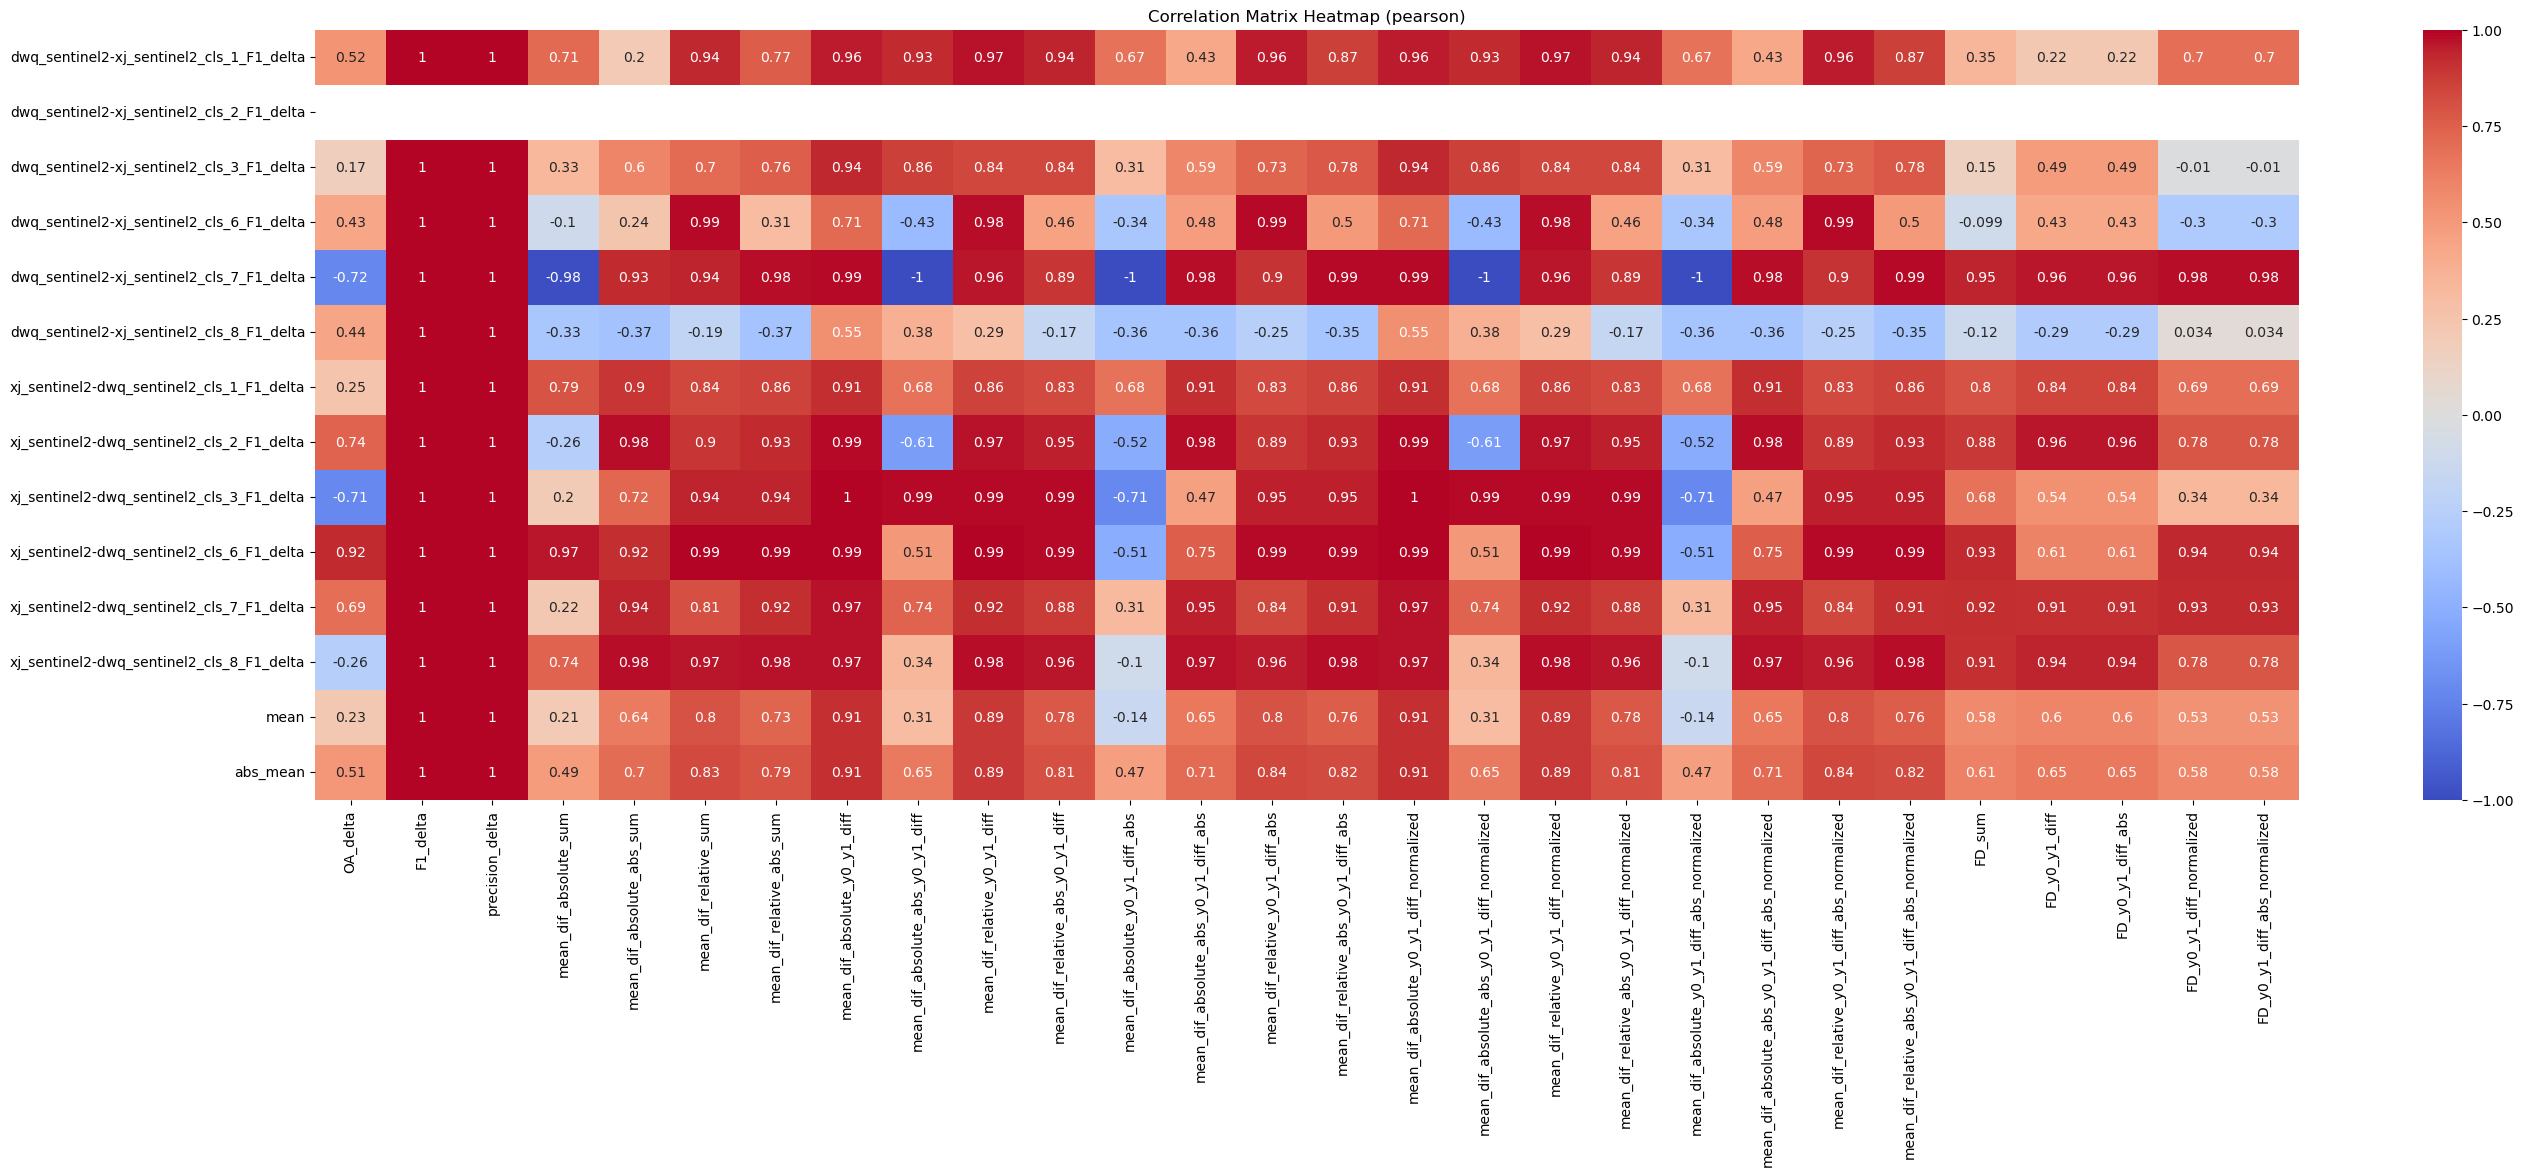

(14, 28)


In [6]:
# plot the correlation matrix heatmap
heatmap_data = df_corr_F1_diff.iloc[:, :]
figsize_scale = 4
plt.figure(figsize=(8 * figsize_scale, 2.5 * figsize_scale))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title(f'Correlation Matrix Heatmap ({correlation_method})')
plt.show()
print(heatmap_data.shape)

In [ ]:
csv_name = f"./csv/{dataset_name_source_list[0]}-{dataset_name_target_list[0]}_" + \
    f"batch{batch_size}_" + \
    f"{index_name}_{transfer_metric_name}_" + \
    f"{correlation_method}_" + \
    "corr_heatmap_data.csv"
heatmap_data.to_csv(csv_name)